In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['Condition'] = 'GH'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['Condition'] = 'SI'


df = pd.concat([df1, df2], ignore_index=True)

df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'}) 

df = df.sort_values(['Condition','file', 'track_id', 'rel_frame'])


si = df[df['Condition'] == 'SI'].copy()
gh = df[df['Condition'] == 'GH'].copy()

metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['Condition', 'file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/1913874345.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


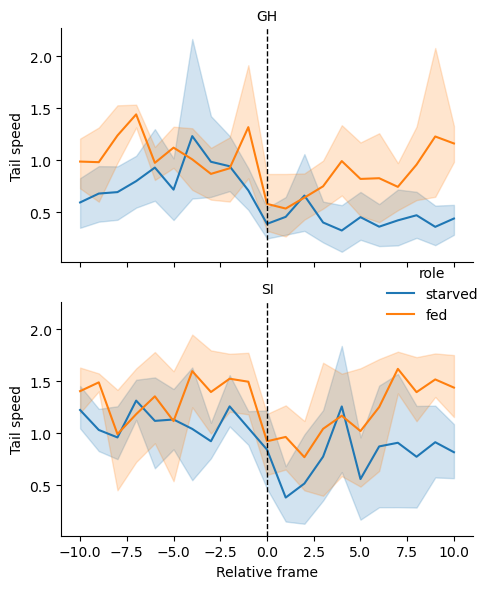

In [6]:
first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']


g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'Tail speed')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/1163735768.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


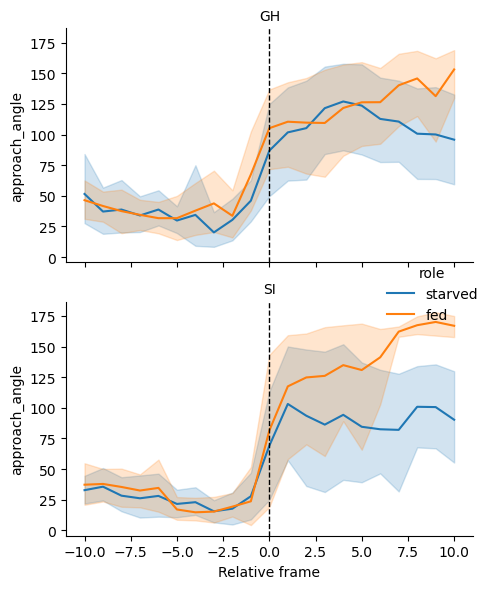

In [7]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='approach_angle',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'approach_angle')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/1169788824.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


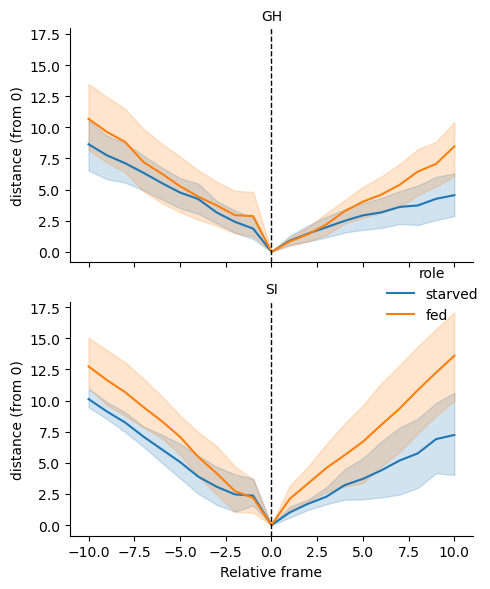

In [8]:
g = sns.relplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='role',
    row='Condition',
    kind='line',
    errorbar=('ci', 95),
    height=3,
    aspect=1.3
)

g.set_axis_labels('Relative frame', 'distance (from 0)')
g.set_titles(row_template='{row_name}', col_template='{col_name}')

for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/group-housed/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/group-housed/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/group-housed/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/food-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

gh_order = ['GH Fed-Fed', 'GH Fed-Starved', 'GH Starved-Starved']
si_order = ['SI Fed-Fed', 'SI Fed-Starved', 'SI Starved-Starved']

palette_gh = {
    'GH Fed-Fed': '#4C72B0',
    'GH Fed-Starved': '#55A868',
    'GH Starved-Starved': '#C44E52',
}

palette_si = {
    'SI Fed-Fed': '#4C72B0',
    'SI Fed-Starved': '#55A868',
    'SI Starved-Starved': '#C44E52',
}

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

si = si.sort_values(['Condition', 'file', 'start_frame'])
gh = gh.sort_values(['Condition', 'file', 'start_frame'])

si['interaction_number'] = (
    si.groupby(['Condition', 'file']).cumcount() + 1
)

gh['interaction_number'] = (
    gh.groupby(['Condition', 'file']).cumcount() + 1
)

df = pd.concat([gh, si], ignore_index=True)

initial_type_order = sorted(df['initial_type'].dropna().unique())


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/1532052914.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/1532052914.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


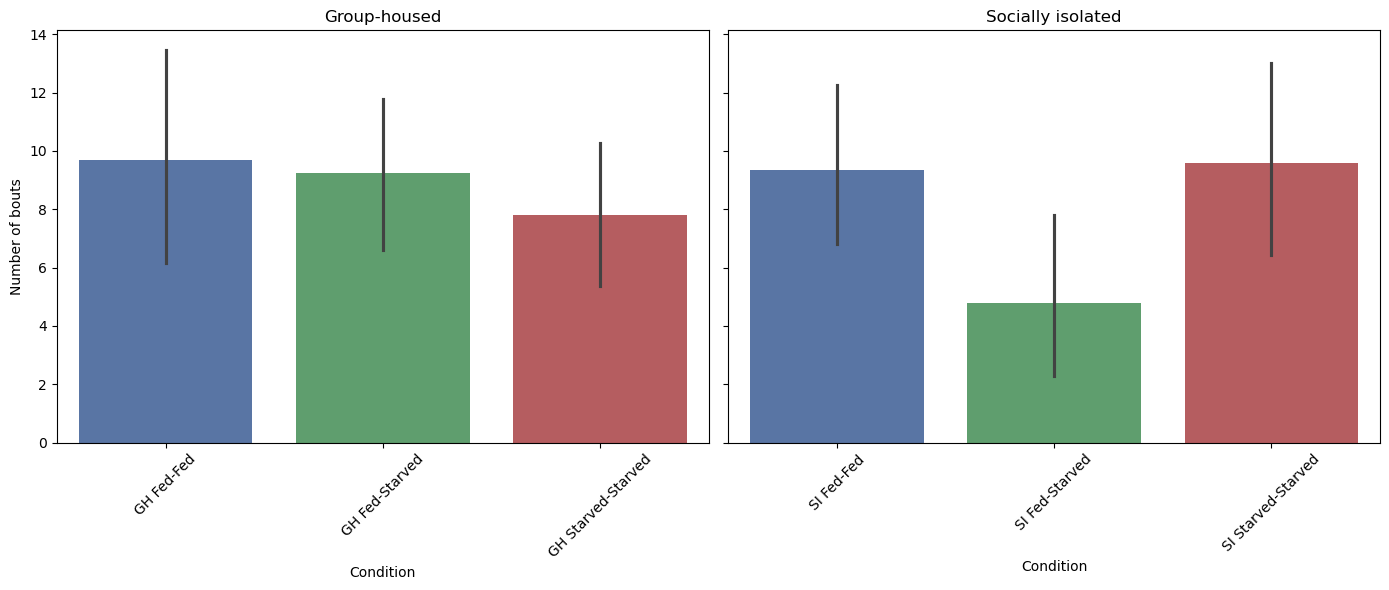

In [10]:
# Number of bouts per file
bout_counts = (
    df.groupby(['Condition', 'file'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)

gh_counts = bout_counts[bout_counts['Condition'].str.contains('GH')].copy()
si_counts = bout_counts[bout_counts['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_counts,
    x='Condition',
    y='n_bouts',
    order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Number of bouts')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.barplot(
    data=si_counts,
    x='Condition',
    y='n_bouts',
    order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/3613729833.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_14471/3613729833.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


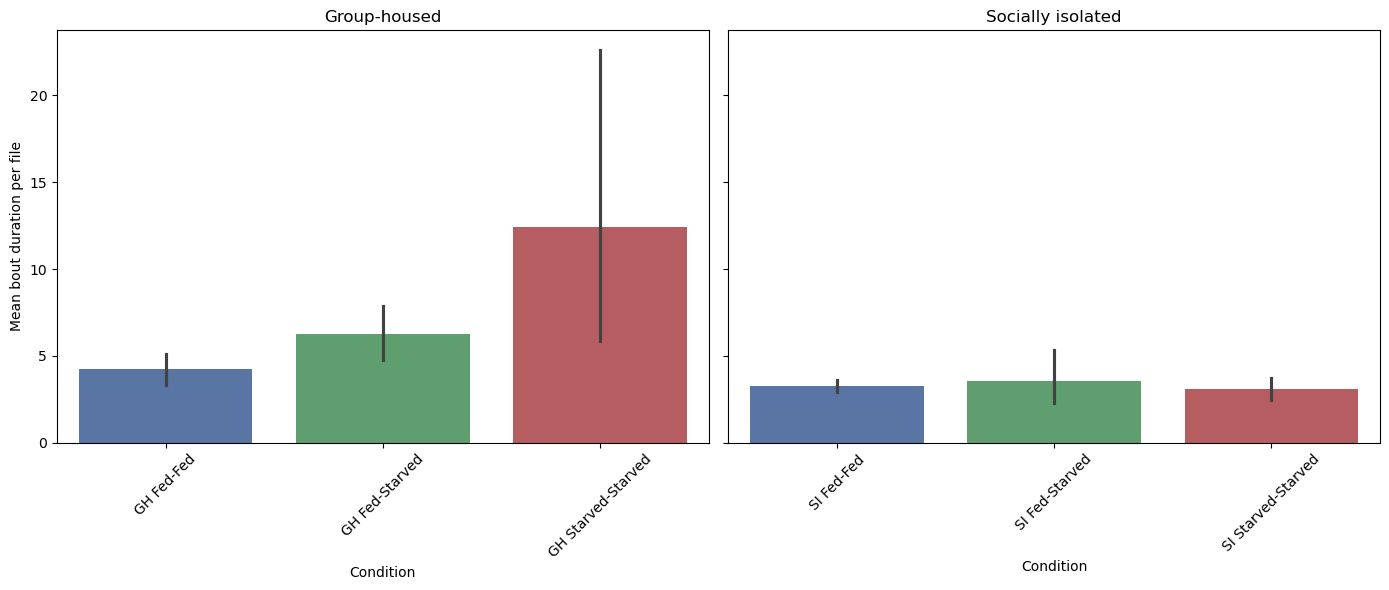

In [11]:
# Mean bout duration per file
duration_per_file = (
    df.groupby(['Condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

gh_duration = duration_per_file[duration_per_file['Condition'].str.contains('GH')].copy()
si_duration = duration_per_file[duration_per_file['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_duration,
    x='Condition',
    y='mean_bout_duration',
    order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean bout duration per file')
axes[0].tick_params(axis='x', rotation=45)

# ---------------- SI ----------------
sns.barplot(
    data=si_duration,
    x='Condition',
    y='mean_bout_duration',
    order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


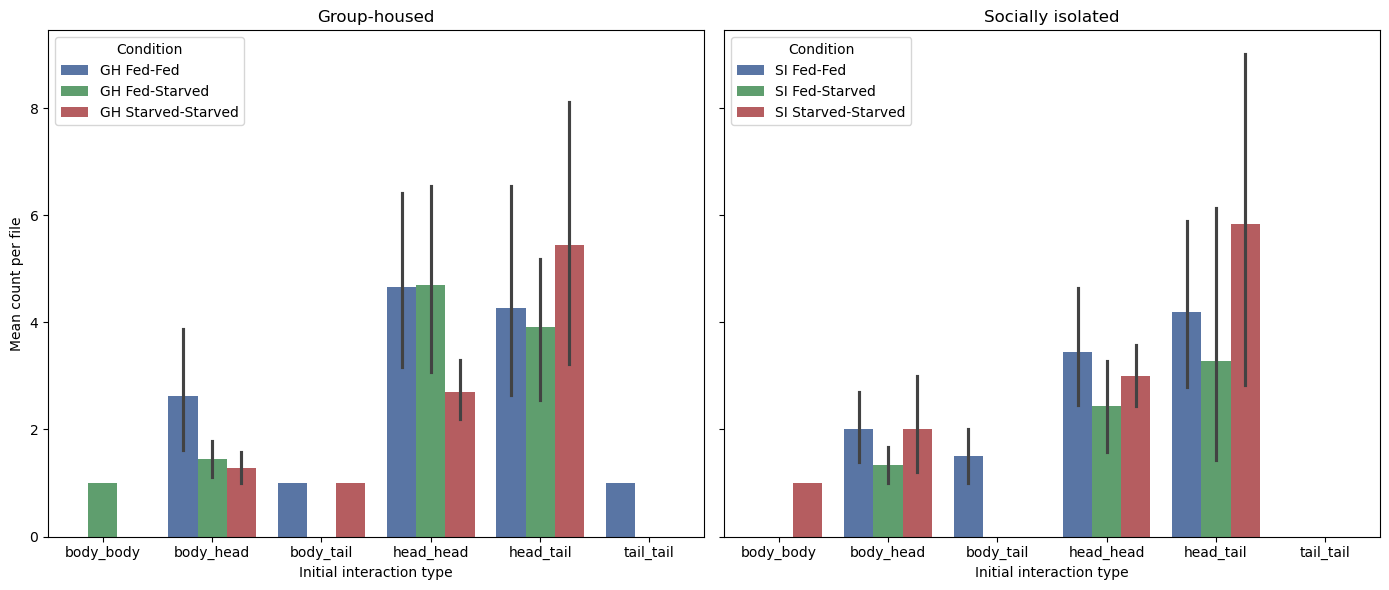

In [12]:
# Mean count per file for each initial interaction type
counts = (
    df.groupby(['Condition', 'file', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

gh_counts = counts[counts['Condition'].str.contains('GH')].copy()
si_counts = counts[counts['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_counts,
    x='initial_type',
    y='count',
    hue='Condition',
    order=initial_type_order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Mean count per file')

# ---------------- SI ----------------
sns.barplot(
    data=si_counts,
    x='initial_type',
    y='count',
    hue='Condition',
    order=initial_type_order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


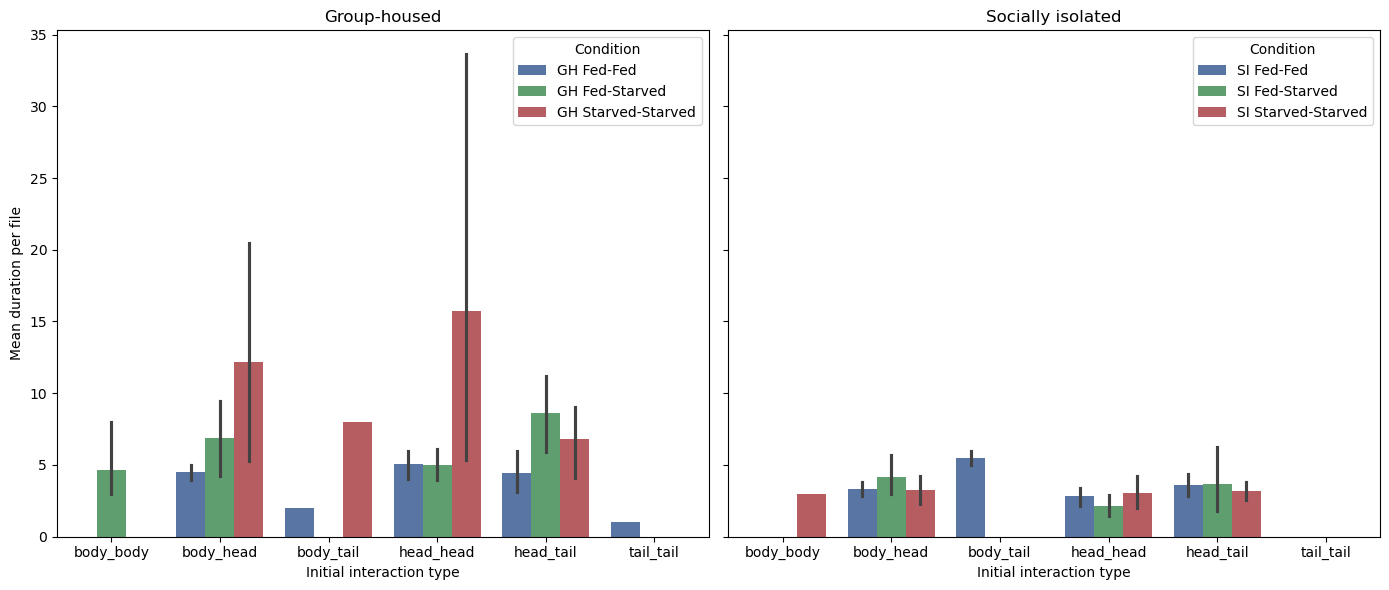

In [13]:
# Mean duration per file for each initial interaction type
duration_by_type = (
    df.groupby(['Condition', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)

gh_duration_by_type = duration_by_type[duration_by_type['Condition'].str.contains('GH')].copy()
si_duration_by_type = duration_by_type[duration_by_type['Condition'].str.contains('SI')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------- GH ----------------
sns.barplot(
    data=gh_duration_by_type,
    x='initial_type',
    y='duration',
    hue='Condition',
    order=initial_type_order,
    hue_order=gh_order,
    palette=palette_gh,
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Initial interaction type')
axes[0].set_ylabel('Mean duration per file')

# ---------------- SI ----------------
sns.barplot(
    data=si_duration_by_type,
    x='initial_type',
    y='duration',
    hue='Condition',
    order=initial_type_order,
    hue_order=si_order,
    palette=palette_si,
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Initial interaction type')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
